## Notebook 09 — Final Model Comparison
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Aggregated comparison of all three models across ML and industrial metrics, with a master summary figure


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import os

In [2]:
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
CLASS_ORDER = sorted(CLASSES)   # sklearn orders classes alphabetically

In [3]:
# Loads confusion matrices, scalar accuracy values, and industrial metric CSVs for all three models

baseline_cm = np.load(os.path.join(RESULTS_PATH, 'baseline_confusion_matrix.npy'))
rf_cm       = np.load(os.path.join(RESULTS_PATH, 'rf_confusion_matrix.npy'))
mlp_cm      = np.load(os.path.join(RESULTS_PATH, 'mlp_confusion_matrix.npy'))

with open(os.path.join(RESULTS_PATH, 'baseline_accuracy.txt'), 'r') as f:
    cont = f.read().strip()
    baseline_acc = float(cont.split(':')[1].strip().split()[0])

with open(os.path.join(RESULTS_PATH, 'rf_accuracy.txt'), 'r') as f:
    rf_acc = float(f.read().strip())

with open(os.path.join(RESULTS_PATH, 'mlp_accuracy.txt'), 'r') as f:
    mlp_acc = float(f.read().strip())

rf_ind  = pd.read_csv(os.path.join(RESULTS_PATH, 'rf_industrial_metrics.csv'))
mlp_ind = pd.read_csv(os.path.join(RESULTS_PATH, 'mlp_industrial_metrics.csv'))

print(f"Baseline accuracy: {baseline_acc:.4f}")
print(f"RF accuracy:       {rf_acc:.4f}")
print(f"MLP accuracy:      {mlp_acc:.4f}")
print("\nAll files loaded successfully.")

Baseline accuracy: 0.2450
RF accuracy:       0.7895
MLP accuracy:      0.8053

All files loaded successfully.


In [4]:
# Reconstructs true and predicted label arrays from a confusion matrix to compute sklearn F1 scores at full floating-point precision

def f1_from_cm(cm, average):
    """
    Reconstruct true and predicted label arrays from a confusion matrix,
    then compute F1 using sklearn at full precision.
    """
    y_true = []
    y_pred = []
    
    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            count = cm[i, j]
            y_true.extend([CLASS_ORDER[i]] * count)
            y_pred.extend([CLASS_ORDER[j]] * count)
    
    return f1_score(y_true, y_pred, average=average)

baseline_f1_weighted = f1_from_cm(baseline_cm, 'weighted')
baseline_f1_macro    = f1_from_cm(baseline_cm, 'macro')

rf_f1_weighted = f1_from_cm(rf_cm, 'weighted')
rf_f1_macro    = f1_from_cm(rf_cm, 'macro')

mlp_f1_weighted = f1_from_cm(mlp_cm, 'weighted')
mlp_f1_macro    = f1_from_cm(mlp_cm, 'macro')

print(f"{'Model':<12} {'Weighted F1':>12} {'Macro F1':>10}")
print("-" * 36)
print(f"{'Baseline':<12} {baseline_f1_weighted:>12.4f} {baseline_f1_macro:>10.4f}")
print(f"{'RF':<12} {rf_f1_weighted:>12.4f} {rf_f1_macro:>10.4f}")
print(f"{'MLP':<12} {mlp_f1_weighted:>12.4f} {mlp_f1_macro:>10.4f}")

Model         Weighted F1   Macro F1
------------------------------------
Baseline           0.1943     0.1749
RF                 0.7898     0.7747
MLP                0.8055     0.7914


In [5]:
# Re-derives purity, yield, and recovery for the baseline model, which was not computed in notebook 08

def compute_industrial_metrics(cm, classes):
    results = []
    for i, cls in enumerate(classes):
        TP = cm[i, i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP
        
        purity   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        yield_   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        recovery = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
        
        results.append({
            'Class':    cls,
            'Purity':   round(purity, 4),
            'Yield':    round(yield_, 4),
            'Recovery': round(recovery, 4)
        })
    return pd.DataFrame(results)

baseline_ind = compute_industrial_metrics(baseline_cm, CLASS_ORDER)

print("Baseline Industrial Metrics:")
print(baseline_ind.to_string(index=False))
print(f"\nMacro Purity:    {baseline_ind['Purity'].mean():.4f}")
print(f"Macro Yield:     {baseline_ind['Yield'].mean():.4f}")
print(f"Macro Recovery:  {baseline_ind['Recovery'].mean():.4f}")

Baseline Industrial Metrics:
    Class  Purity  Yield  Recovery
cardboard  0.4286 0.2459    0.1852
    glass  0.2351 0.7867    0.2210
    metal  0.3750 0.0968    0.0833
    paper  0.3333 0.0787    0.0680
  plastic  0.1071 0.0833    0.0492
    trash  0.0000 0.0000    0.0000

Macro Purity:    0.2465
Macro Yield:     0.2152
Macro Recovery:  0.1011


In [6]:
# Assembles a unified comparison table of accuracy, F1, and industrial metrics across all three models

comparison = pd.DataFrame({
    'Model':        ['Baseline', 'Random Forest', 'MLP'],
    'Accuracy':     [baseline_acc, rf_acc, mlp_acc],
    'Weighted F1':  [baseline_f1_weighted, rf_f1_weighted, mlp_f1_weighted],
    'Macro F1':     [baseline_f1_macro, rf_f1_macro, mlp_f1_macro],
    'Purity':       [baseline_ind['Purity'].mean(),
                     rf_ind['Purity'].mean(),
                     mlp_ind['Purity'].mean()],
    'Yield':        [baseline_ind['Yield'].mean(),
                     rf_ind['Yield'].mean(),
                     mlp_ind['Yield'].mean()],
    'Recovery':     [baseline_ind['Recovery'].mean(),
                     rf_ind['Recovery'].mean(),
                     mlp_ind['Recovery'].mean()]
}).round(4)

print("=" * 50)
print("MASTER MODEL COMPARISON TABLE")
print("=" * 50)
print(comparison.to_string(index=False))

MASTER MODEL COMPARISON TABLE
        Model  Accuracy  Weighted F1  Macro F1  Purity  Yield  Recovery
     Baseline    0.2450       0.1943    0.1749  0.2465 0.2152    0.1011
Random Forest    0.7895       0.7898    0.7747  0.7993 0.7612    0.6381
          MLP    0.8053       0.8055    0.7914  0.7965 0.7876    0.6605


In [7]:
comparison.to_csv(os.path.join(RESULTS_PATH, 'master_comparison.csv'), index=False)
print("\nSaved: master_comparison.csv")


Saved: master_comparison.csv


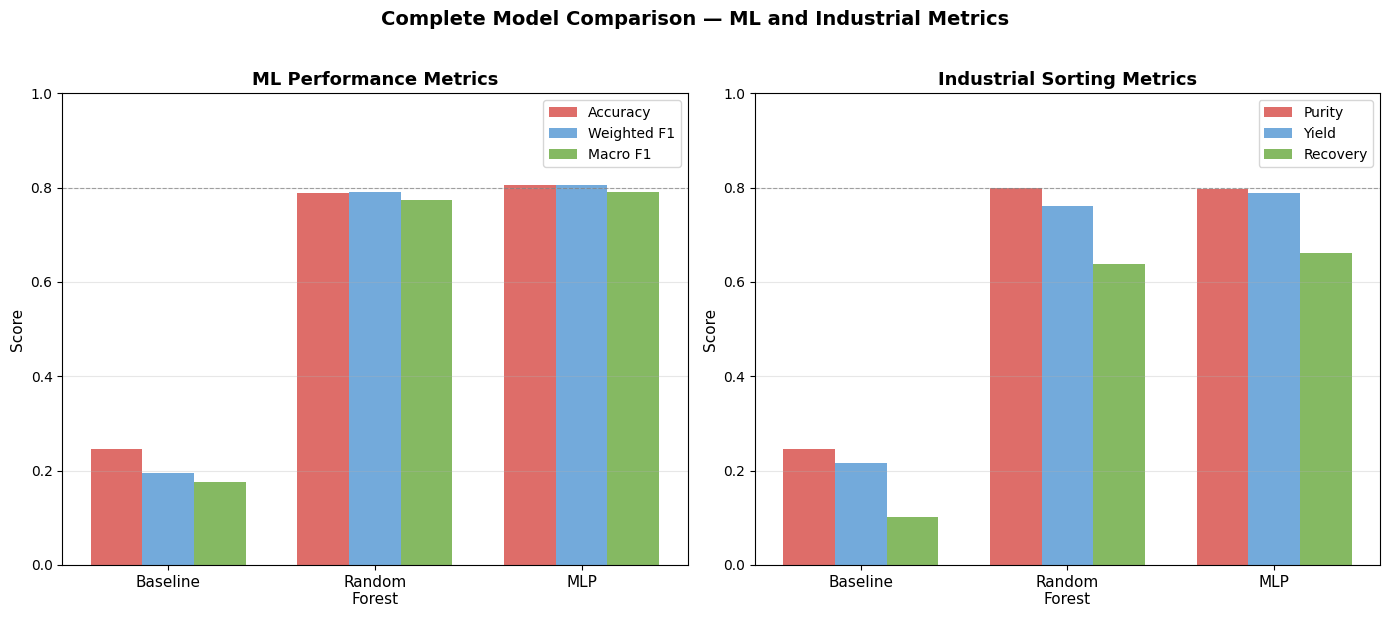

Saved: master_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models  = ['Baseline', 'Random\nForest', 'MLP']
colors  = ['#d9534f', '#5b9bd5', '#70ad47']
x       = np.arange(len(models))
width   = 0.25

ax = axes[0]
ax.bar(x - width, comparison['Accuracy'],    width, label='Accuracy',     color=colors[0], alpha=0.85)
ax.bar(x,         comparison['Weighted F1'], width, label='Weighted F1',  color=colors[1], alpha=0.85)
ax.bar(x + width, comparison['Macro F1'],    width, label='Macro F1',     color=colors[2], alpha=0.85)

ax.set_title('ML Performance Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - width, comparison['Purity'],   width, label='Purity',   color=colors[0], alpha=0.85)
ax.bar(x,         comparison['Yield'],    width, label='Yield',     color=colors[1], alpha=0.85)
ax.bar(x + width, comparison['Recovery'], width, label='Recovery',  color=colors[2], alpha=0.85)

ax.set_title('Industrial Sorting Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Complete Model Comparison — ML and Industrial Metrics',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'master_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: master_comparison.png")

### Five-model comparison

Notebook 14 added a logistic regression and a linear SVC on the same 122-dim feature vector
and the same split, so the comparison above is no longer the full picture. This section
rebuilds it with all five models.

Everything above is left as it was: `master_comparison.csv` and `master_comparison.png`
still hold the three-model version that the earlier write-up refers to. The five-model
outputs are written alongside them under `master_comparison_all.*`. The three shared rows
are taken from the `comparison` frame built above rather than recomputed, and the two new
rows go through the same `f1_from_cm` helper, so the two tables cannot disagree.

In [9]:
# Loads the linear model artifacts written by notebook 14, in the same order the earlier
# cells load the other three

logreg_cm = np.load(os.path.join(RESULTS_PATH, 'logreg_confusion_matrix.npy'))
linsvc_cm = np.load(os.path.join(RESULTS_PATH, 'linsvc_confusion_matrix.npy'))

with open(os.path.join(RESULTS_PATH, 'logreg_accuracy.txt'), 'r') as f:
    logreg_acc = float(f.read().strip())

with open(os.path.join(RESULTS_PATH, 'linsvc_accuracy.txt'), 'r') as f:
    linsvc_acc = float(f.read().strip())

logreg_ind = pd.read_csv(os.path.join(RESULTS_PATH, 'logreg_industrial_metrics.csv'))
linsvc_ind = pd.read_csv(os.path.join(RESULTS_PATH, 'linsvc_industrial_metrics.csv'))

print(f"Logistic Regression accuracy: {logreg_acc:.4f}")
print(f"Linear SVC accuracy:          {linsvc_acc:.4f}")
print("\nLinear model files loaded successfully.")

Logistic Regression accuracy: 0.6895
Linear SVC accuracy:          0.6711

Linear model files loaded successfully.


In [10]:
linear_rows = pd.DataFrame({
    'Model':        ['Linear SVC', 'Logistic Regression'],
    'Accuracy':     [linsvc_acc, logreg_acc],
    'Weighted F1':  [f1_from_cm(linsvc_cm, 'weighted'), f1_from_cm(logreg_cm, 'weighted')],
    'Macro F1':     [f1_from_cm(linsvc_cm, 'macro'),    f1_from_cm(logreg_cm, 'macro')],
    'Purity':       [linsvc_ind['Purity'].mean(),   logreg_ind['Purity'].mean()],
    'Yield':        [linsvc_ind['Yield'].mean(),    logreg_ind['Yield'].mean()],
    'Recovery':     [linsvc_ind['Recovery'].mean(), logreg_ind['Recovery'].mean()]
}).round(4)

# Ordered by accuracy so the table reads as a progression rather than by when each model
# was added
MODEL_ORDER = ['Baseline', 'Linear SVC', 'Logistic Regression', 'Random Forest', 'MLP']

comparison_all = (
    pd.concat([comparison, linear_rows], ignore_index=True)
    .set_index('Model')
    .loc[MODEL_ORDER]
    .reset_index()
)

print("=" * 74)
print("MASTER MODEL COMPARISON TABLE - ALL FIVE MODELS")
print("=" * 74)
print(comparison_all.to_string(index=False))

MASTER MODEL COMPARISON TABLE - ALL FIVE MODELS
              Model  Accuracy  Weighted F1  Macro F1  Purity  Yield  Recovery
           Baseline    0.2450       0.1943    0.1749  0.2465 0.2152    0.1011
         Linear SVC    0.6711       0.6693    0.6620  0.6742 0.6540    0.5082
Logistic Regression    0.6895       0.6879    0.6687  0.6841 0.6591    0.5141
      Random Forest    0.7895       0.7898    0.7747  0.7993 0.7612    0.6381
                MLP    0.8053       0.8055    0.7914  0.7965 0.7876    0.6605


In [11]:
comparison_all.to_csv(os.path.join(RESULTS_PATH, 'master_comparison_all.csv'), index=False)
print("\nSaved: master_comparison_all.csv")


Saved: master_comparison_all.csv


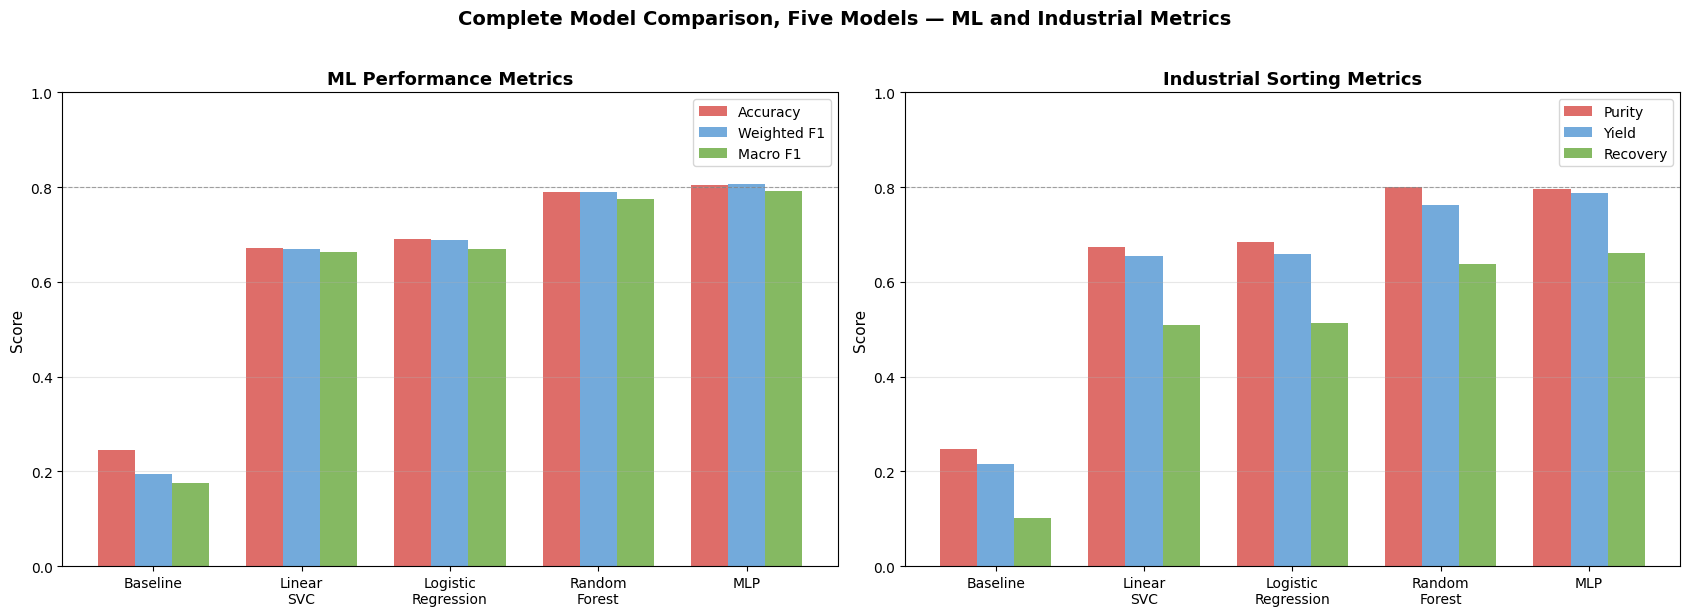

Saved: master_comparison_all.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

models_all = ['Baseline', 'Linear\nSVC', 'Logistic\nRegression', 'Random\nForest', 'MLP']
x_all      = np.arange(len(models_all))

ax = axes[0]
ax.bar(x_all - width, comparison_all['Accuracy'],    width, label='Accuracy',    color=colors[0], alpha=0.85)
ax.bar(x_all,         comparison_all['Weighted F1'], width, label='Weighted F1', color=colors[1], alpha=0.85)
ax.bar(x_all + width, comparison_all['Macro F1'],    width, label='Macro F1',    color=colors[2], alpha=0.85)

ax.set_title('ML Performance Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x_all)
ax.set_xticklabels(models_all, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x_all - width, comparison_all['Purity'],   width, label='Purity',   color=colors[0], alpha=0.85)
ax.bar(x_all,         comparison_all['Yield'],    width, label='Yield',    color=colors[1], alpha=0.85)
ax.bar(x_all + width, comparison_all['Recovery'], width, label='Recovery', color=colors[2], alpha=0.85)

ax.set_title('Industrial Sorting Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x_all)
ax.set_xticklabels(models_all, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Complete Model Comparison, Five Models \u2014 ML and Industrial Metrics',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'master_comparison_all.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: master_comparison_all.png")

In [13]:
# Guards the two tables against drifting: the three shared rows must be identical in both

shared = comparison_all[comparison_all['Model'].isin(comparison['Model'])].reset_index(drop=True)
expected = comparison.set_index('Model').loc[shared['Model']].reset_index()

pd.testing.assert_frame_equal(shared, expected)
print("Baseline, Random Forest and MLP rows are identical in both comparison tables.")

Baseline, Random Forest and MLP rows are identical in both comparison tables.
